# Library

In [20]:
from keras.src.callbacks import CSVLogger, TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.src.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.src.applications.inception_v3 import InceptionV3
from sklearn.model_selection import train_test_split
from keras.src.metrics import Precision, Recall
from opentelemetry.sdk.resources import psutil
from keras.src.utils import to_categorical
from keras.src.optimizers import Adam
import plotly.graph_objects as go
from sklearn.utils import shuffle
from collections import Counter
import matplotlib.pyplot as plt
from keras import Sequential
import plotly.express as px
from GPUtil import GPUtil
import numpy as np
import itertools
import warnings
import mlflow
import time
import glob
import cv2
import os

# PATH & Variable

In [21]:
warnings.filterwarnings('ignore')

VERSION = "v21"

BASE_DIR = "output"
DATASET_DIR = "dataset"

TRAIN_PATH = os.path.join(DATASET_DIR, "training")
PLOT_SAVE_DIR = os.path.join(BASE_DIR, "plot", VERSION)
LOG_DIR = os.path.join(BASE_DIR, "log", VERSION)
MODEL_SAVE_PATH = os.path.join(BASE_DIR, "model", VERSION, "train.keras")
HISTORY_PATH = os.path.join(BASE_DIR, "model", VERSION, "train_history.npy")

IMAGE_SIZE = (224, 224)
INPUT_SHAPE = (IMAGE_SIZE, 3)
BATCH_SIZE = 32
EPOCHS = 75
LEARNING_RATE = 1e-3
FINE_TUNE_EPOCHS = 25
FINE_TUNE_LR = 1e-4

TRAIN_SIZE = 3200
VAL_SIZE = 600
TEST_SIZE = 200

CLASS_NAMES = sorted([os.path.basename(d) for d in glob.glob(os.path.join(TRAIN_PATH, "*")) if os.path.isdir(d)])
NB_CLASSES = len(CLASS_NAMES)

LABEL_MAPPING = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

print(f"Model Version: {VERSION}")
print(f"Train Path: {TRAIN_PATH}")
print(f"{NB_CLASSES} Classes: {CLASS_NAMES}")

for directory in [PLOT_SAVE_DIR, LOG_DIR, os.path.dirname(MODEL_SAVE_PATH)]:
    os.makedirs(directory, exist_ok=True)

Model Version: v21
Train Path: dataset/training
4 Classes: ['alcohol', 'blood', 'sexual', 'traffic_accident']


# Load Data

In [22]:
def load_data(dataset, label_mapping, image_size=(224, 224)):
    images, labels = [], []
    for folder in os.listdir(dataset):
        if folder not in label_mapping:
            continue
        label = label_mapping[folder]
        folder_path = os.path.join(dataset, folder)
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(label)
    return np.array(images, dtype='float32'), np.array(labels, dtype='int')

# Execute images and labels

In [23]:
images, labels = load_data(TRAIN_PATH, LABEL_MAPPING)
images, labels = shuffle(images, labels, random_state=42)

In [24]:
# Stratified Split
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, stratify=labels, test_size=0.2, random_state=42)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, stratify=temp_labels, test_size=0.5, random_state=42)

In [25]:
train_labels = to_categorical(train_labels, num_classes=NB_CLASSES)
val_labels = to_categorical(val_labels, num_classes=NB_CLASSES)
test_labels = to_categorical(test_labels, num_classes=NB_CLASSES)

# Data Augmentation

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=30,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE, shuffle=True, seed=42)
valid_generator = val_datagen.flow(val_images, val_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)


# Visualize dataset

In [27]:
train_labels_int = np.argmax(train_labels, axis=1)

class_counts = Counter(train_labels_int)

class_labels = [CLASS_NAMES[label] for label in class_counts.keys()]
counts = list(class_counts.values())

fig = px.bar(
    x=class_labels,
    y=counts,
    template='plotly_dark',
    color=class_labels,
    title='Number of Images per Class in Train Data',
    labels={'x': 'Class Label', 'y': 'Count of Images'},
    text=counts
)

fig.update_layout(
    xaxis_title='Class Label',
    yaxis_title='Count of Images',
    showlegend=False
)

fig.show()

In [28]:
train_labels_int = np.argmax(train_labels, axis=1)
val_labels_int = np.argmax(val_labels, axis=1)
test_labels_int = np.argmax(test_labels, axis=1)

train_counts = [Counter(train_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]
val_counts = [Counter(val_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]
test_counts = [Counter(test_labels_int).get(i, 0) for i in range(len(CLASS_NAMES))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=train_counts,
    name='Train',
    marker=dict(color='blue'),
    text=train_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=val_counts,
    name='Validation',
    marker=dict(color='green'),
    text=val_counts,
    textposition='auto'
))
fig.add_trace(go.Bar(
    x=CLASS_NAMES,
    y=test_counts,
    name='Test',
    marker=dict(color='red'),
    text=test_counts,
    textposition='auto'
))

fig.update_layout(
    title="Number of Images per Class in Train, Validation, and Test Data",
    barmode='group',
    xaxis_title="Class",
    yaxis_title="Number of Images",
    template="plotly_dark"
)

fig.show()

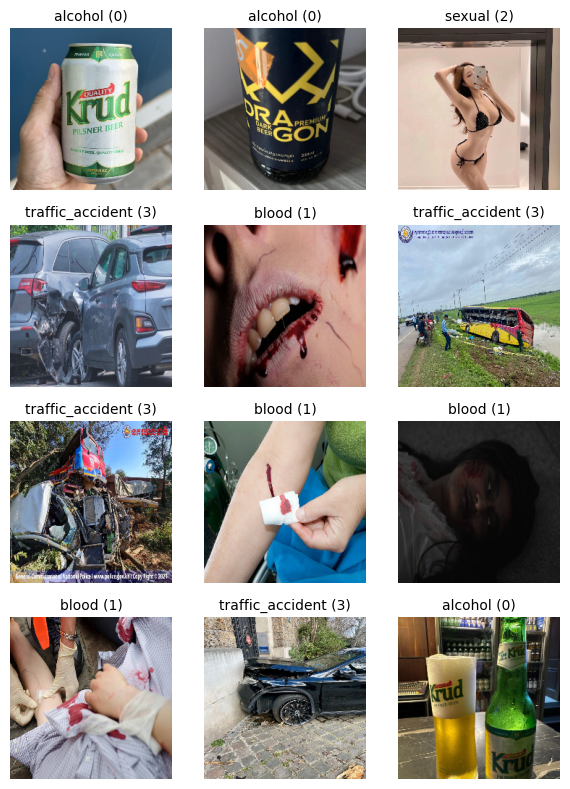

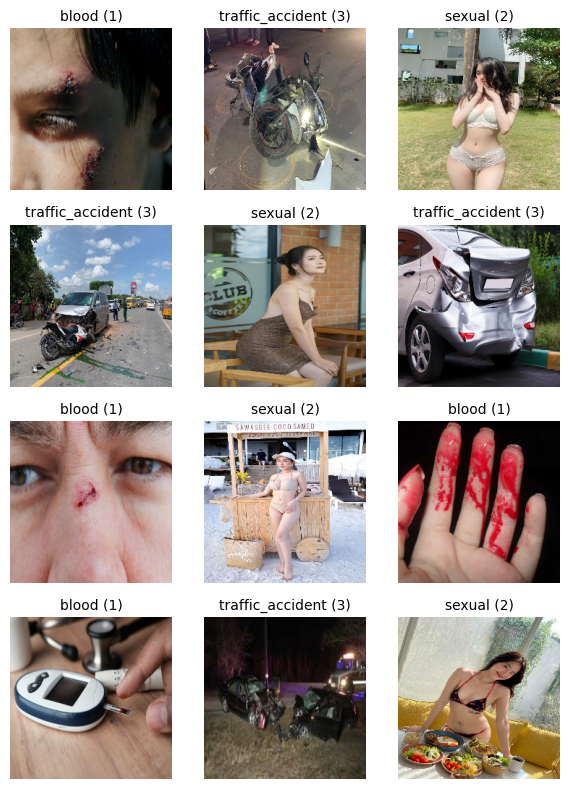

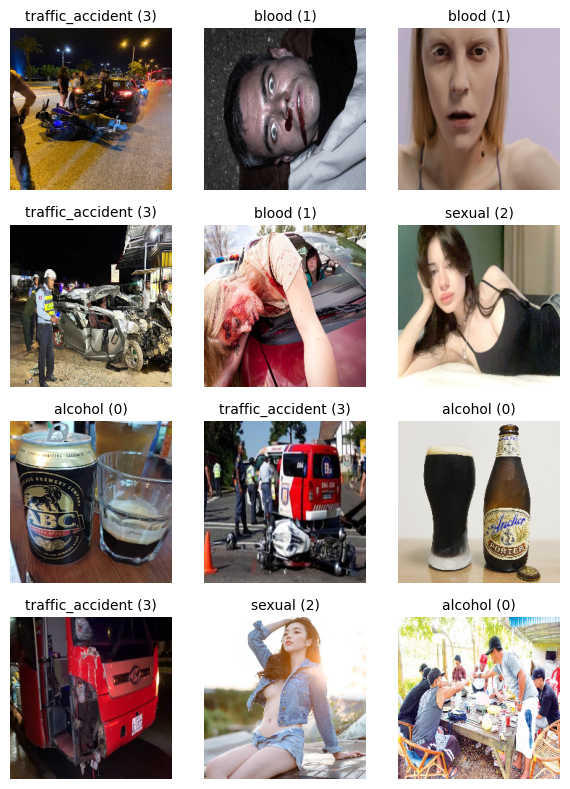

In [29]:
def display_dataset(class_names, images, labels, num_images=12):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)
    cols = int(np.sqrt(num_images))
    rows = (num_images + cols - 1) // cols
    plt.figure(figsize=(6, 6 * rows / cols))

    for i, idx in enumerate(random_indices):
        image = images[idx]
        label = labels[idx]

        if labels.ndim > 1:
            label = np.argmax(label)
        class_name = class_names[label]

        if image.dtype == np.uint8:
            display_image = image
        else:
            display_image = np.clip(image / 255.0, 0, 1)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(display_image)
        plt.title(f"{class_name} ({label})", fontsize=10, color='black')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Display Training Dataset
display_dataset(CLASS_NAMES, train_images, train_labels)

# Display Validation Dataset
display_dataset(CLASS_NAMES, val_images, val_labels)

# Display Testing Dataset
display_dataset(CLASS_NAMES, test_images, test_labels)

# Model architecture

In [30]:
# Load Pretrained Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
base_model.trainable = False

# Custom Top Layers
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(NB_CLASSES, activation='softmax')
])

# Compile Model
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# Summary Model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_190         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_191         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,362,276 (85.31 MB)

 Trainable params: 558,724 (2.13 MB)

 Non-trainable params: 21,803,552 (83.17 MB)

# Compile the model

In [31]:
# Callbacks
callbacks = [
    CSVLogger(os.path.join(LOG_DIR, 'training_log.csv'), append=False),
    TensorBoard(log_dir=os.path.join(LOG_DIR, "tensorboard_logs"), histogram_freq=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

# MLflow Logging
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment("Transfer_Learning_Training")
mlflow.tensorflow.autolog()


def log_system_metrics():
    cpu_usage = psutil.cpu_percent(interval=1)
    memory_usage = psutil.virtual_memory().percent
    disk_usage = psutil.disk_usage("/").percent

    mlflow.log_metric("CPU_Usage", cpu_usage)
    mlflow.log_metric("Memory_Usage", memory_usage)
    mlflow.log_metric("Disk_Usage", disk_usage)

    gpus = GPUtil.getGPUs()
    for i, gpu in enumerate(gpus):
        mlflow.log_metric(f"GPU_{i}_Usage", gpu.load * 100)
        mlflow.log_metric(f"GPU_{i}_Memory", gpu.memoryUtil * 100)


with mlflow.start_run():
    start_time = time.time()

    mlflow.log_param("train_dataset_size", len(train_generator))
    mlflow.log_param("validation_dataset_size", len(valid_generator))
    mlflow.log_param("test_dataset_size", len(test_generator))
    mlflow.log_param("class_names", str(CLASS_NAMES))

    log_system_metrics()

    history = model.fit(train_generator, validation_data=valid_generator, epochs=EPOCHS, callbacks=callbacks, verbose=2)

    log_system_metrics()
    mlflow.log_metric("training_time_sec", time.time() - start_time)

    model.save(MODEL_SAVE_PATH)
    np.save(HISTORY_PATH, history.history)

    print("✅ Initial Training Complete!")

for layer in base_model.layers[-30:]:
    layer.trainable = True

fine_tune_optimizer = Adam(learning_rate=FINE_TUNE_LR)
model.compile(optimizer=fine_tune_optimizer, loss='categorical_crossentropy',
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

with mlflow.start_run():
    start_time = time.time()
    mlflow.log_param("fine_tune_learning_rate", FINE_TUNE_LR)

    log_system_metrics()

    fine_tune_history = model.fit(train_generator, validation_data=valid_generator, epochs=FINE_TUNE_EPOCHS,
                                  callbacks=callbacks, verbose=2)

    log_system_metrics()
    mlflow.log_metric("fine_tuning_time_sec", time.time() - start_time)

    model.save(MODEL_SAVE_PATH.replace(".keras", "_fine_tuned.keras"))
    np.save(HISTORY_PATH.replace(".npy", "_fine_tuned.npy"), fine_tune_history.history)

    print("✅ Fine-Tuning Complete!")

2025/02/25 15:49:05 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.
2025/02/25 15:49:05 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.


Epoch 1/75

Epoch 1: val_loss improved from inf to 0.14721, saving model to output/model/v21/train.keras


100/100 - 89s - 888ms/step - accuracy: 0.8356 - loss: 0.4575 - precision: 0.8607 - recall: 0.8169 - val_accuracy: 0.9500 - val_loss: 0.1472 - val_precision: 0.9519 - val_recall: 0.9400 - learning_rate: 0.0010
Epoch 2/75

Epoch 2: val_loss did not improve from 0.14721
100/100 - 89s - 888ms/step - accuracy: 0.8981 - loss: 0.2921 - precision: 0.9092 - recall: 0.8888 - val_accuracy: 0.9300 - val_loss: 0.1974 - val_precision: 0.9342 - val_recall: 0.9225 - learning_rate: 0.0010
Epoch 3/75

Epoch 3: val_loss did not improve from 0.14721
100/100 - 85s - 853ms/step - accuracy: 0.9091 - loss: 0.2602 - precision: 0.9216 - recall: 0.8997 - val_accuracy: 0.9350 - val_loss: 0.1812 - val_precision: 0.9466 - val_recall: 0.9300 - learning_rate: 0.0010
Epoch 4/75

Epoch 4: val_loss improved from 0.14721 to 0.12423, saving model to output/model/v21/train.keras


100/100 - 82s - 824ms/step - accuracy: 0.9109 - loss: 0.2559 - precision: 0.9215 - recall: 0.9056 - val_accuracy: 0.9600 - val_loss: 0.1242 - val_precision: 0.9697 - val_recall: 0.9600 - learning_rate: 0.0010
Epoch 5/75

Epoch 5: val_loss did not improve from 0.12423
100/100 - 79s - 789ms/step - accuracy: 0.9172 - loss: 0.2306 - precision: 0.9257 - recall: 0.9112 - val_accuracy: 0.9525 - val_loss: 0.1277 - val_precision: 0.9544 - val_recall: 0.9425 - learning_rate: 0.0010
Epoch 6/75

Epoch 6: val_loss did not improve from 0.12423
100/100 - 83s - 834ms/step - accuracy: 0.9241 - loss: 0.2264 - precision: 0.9323 - recall: 0.9166 - val_accuracy: 0.9425 - val_loss: 0.1363 - val_precision: 0.9496 - val_recall: 0.9425 - learning_rate: 0.0010
Epoch 7/75

Epoch 7: val_loss improved from 0.12423 to 0.10662, saving model to output/model/v21/train.keras


100/100 - 75s - 753ms/step - accuracy: 0.9237 - loss: 0.2105 - precision: 0.9312 - recall: 0.9175 - val_accuracy: 0.9675 - val_loss: 0.1066 - val_precision: 0.9722 - val_recall: 0.9625 - learning_rate: 0.0010
Epoch 8/75

Epoch 8: val_loss improved from 0.10662 to 0.10116, saving model to output/model/v21/train.keras


...

100/100 - 84s - 835ms/step - accuracy: 0.9847 - loss: 0.0493 - precision: 0.9853 - recall: 0.9828 - val_accuracy: 0.9675 - val_loss: 0.0678 - val_precision: 0.9675 - val_recall: 0.9675 - learning_rate: 5.0000e-05
Epoch 13/25

Epoch 13: val_loss improved from 0.06779 to 0.05984, saving model to output/model/v21/train.keras


100/100 - 86s - 858ms/step - accuracy: 0.9841 - loss: 0.0520 - precision: 0.9847 - recall: 0.9825 - val_accuracy: 0.9750 - val_loss: 0.0598 - val_precision: 0.9774 - val_recall: 0.9750 - learning_rate: 5.0000e-05
Epoch 14/25

Epoch 14: val_loss did not improve from 0.05984
100/100 - 83s - 835ms/step - accuracy: 0.9834 - loss: 0.0521 - precision: 0.9847 - recall: 0.9831 - val_accuracy: 0.9800 - val_loss: 0.0606 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 15/25

Epoch 15: val_loss did not improve from 0.05984
100/100 - 84s - 838ms/step - accuracy: 0.9797 - loss: 0.0564 - precision: 0.9809 - recall: 0.9787 - val_accuracy: 0.9800 - val_loss: 0.0658 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 5.0000e-05
Epoch 16/25

Epoch 16: val_loss did not improve from 0.05984
100/100 - 83s - 831ms/step - accuracy: 0.9819 - loss: 0.0498 - precision: 0.9834 - recall: 0.9806 - val_accuracy: 0.9800 - val_loss: 0.0620 - val_precision: 0.9799 - val_recall: 

100/100 - 84s - 839ms/step - accuracy: 0.9875 - loss: 0.0373 - precision: 0.9890 - recall: 0.9872 - val_accuracy: 0.9800 - val_loss: 0.0578 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 23/25

Epoch 23: val_loss did not improve from 0.05781
100/100 - 83s - 830ms/step - accuracy: 0.9869 - loss: 0.0414 - precision: 0.9878 - recall: 0.9850 - val_accuracy: 0.9800 - val_loss: 0.0646 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 2.5000e-05
Epoch 24/25

Epoch 24: val_loss did not improve from 0.05781
100/100 - 84s - 838ms/step - accuracy: 0.9887 - loss: 0.0350 - precision: 0.9897 - recall: 0.9884 - val_accuracy: 0.9850 - val_loss: 0.0605 - val_precision: 0.9850 - val_recall: 0.9850 - learning_rate: 2.5000e-05
Epoch 25/25

Epoch 25: val_loss did not improve from 0.05781
100/100 - 84s - 836ms/step - accuracy: 0.9903 - loss: 0.0337 - precision: 0.9903 - recall: 0.9894 - val_accuracy: 0.9750 - val_loss: 0.0670 - val_precision: 0.9774 - val_recall: 

2025/02/25 17:11:56 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/02/25 17:11:56 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/02/25 17:12:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
✅ Fine-Tuning Complete!


# Evaluate the model

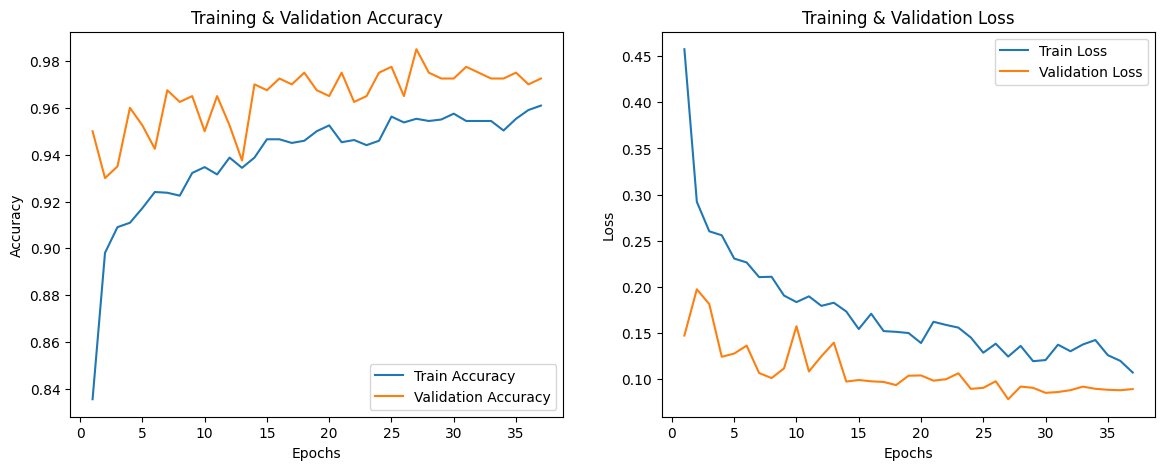

In [32]:
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    plt.savefig(f"{PLOT_SAVE_DIR}training_history.png")
    plt.show()


# Plot Training History
plot_training_history(history)

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 659ms/step

Classification Report:
                   precision    recall  f1-score   support

         alcohol       0.96      0.94      0.95       100
           blood       0.91      0.94      0.93       100
          sexual       0.97      0.96      0.96       100
traffic_accident       1.00      1.00      1.00       100

        accuracy                           0.96       400
       macro avg       0.96      0.96      0.96       400
    weighted avg       0.96      0.96      0.96       400



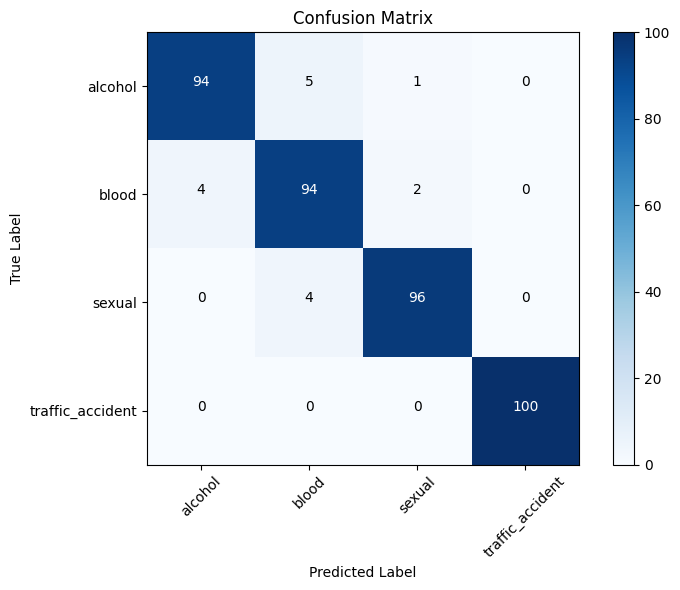

In [33]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

report = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES)
print("\nClassification Report:\n", report)

cm = confusion_matrix(y_true, y_pred_classes)


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{PLOT_SAVE_DIR}confusion_matrix.png")
    plt.show()


plot_confusion_matrix(cm, CLASS_NAMES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


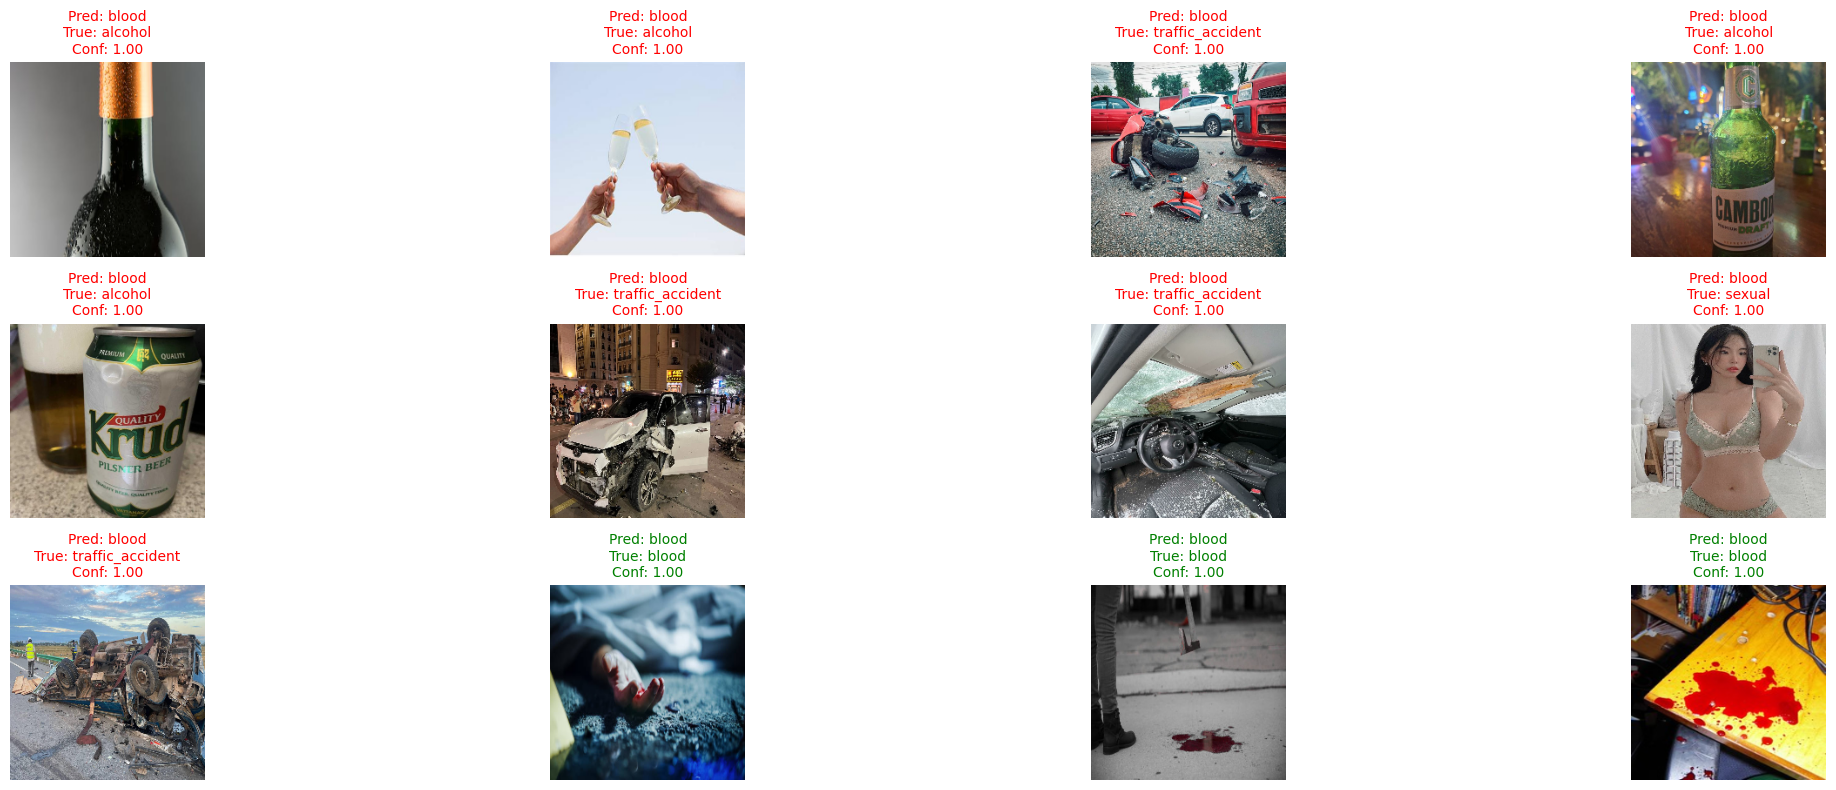

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


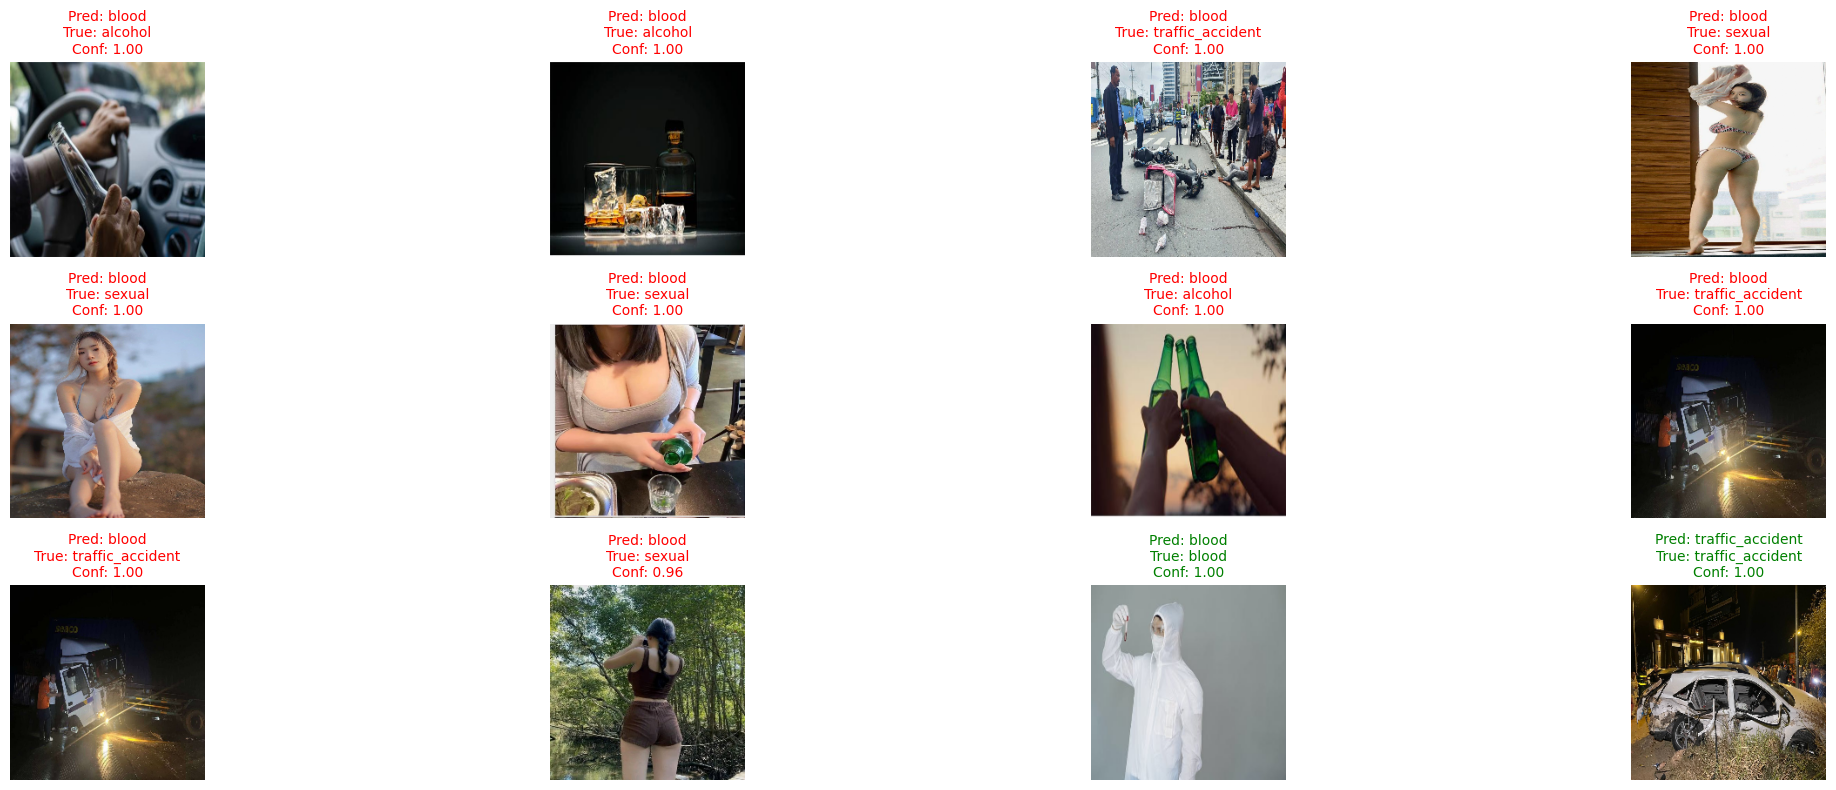

In [34]:
def display_sample_predictions(model, class_names, images, labels, num_images=12):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(num_images * 2, 8))

    misclassified = []
    correct = []

    for idx in random_indices:
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        if predicted_label == true_label:
            correct.append((idx, confidence))
        else:
            misclassified.append((idx, confidence))

    misclassified.sort(key=lambda x: x[1], reverse=True)
    correct.sort(key=lambda x: x[1], reverse=True)

    sorted_indices = [i[0] for i in misclassified + correct]

    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols

    for i, idx in enumerate(sorted_indices[:num_images]):
        image = images[idx]
        true_label = np.argmax(labels[idx])
        img_input = np.expand_dims(image, axis=0)
        prediction = model.predict(img_input)
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        plt.subplot(rows, cols, i + 1)

        # ✅ Normalize image properly
        if image.dtype == np.uint8:
            display_image = image
        else:
            display_image = np.clip(image / 255.0, 0, 1)

        plt.imshow(display_image)
        plt.axis('off')

        title_color = "green" if predicted_label == true_label else "red"
        plt.title(f"Pred: {class_names[predicted_label]}\n"
                  f"True: {class_names[true_label]}\n"
                  f"Conf: {confidence:.2f}",
                  fontsize=10, color=title_color)

    plt.tight_layout()
    plt.savefig(f"{PLOT_SAVE_DIR}sample_predictions.png")
    plt.show()


# ✅ Display Predictions
display_sample_predictions(model, CLASS_NAMES, test_images, test_labels)
display_sample_predictions(model, CLASS_NAMES, val_images, val_labels)